# 02 — Silver `clients_features`

Este notebook construye la tabla analítica `silver.clients_features` para el Módulo 2.

La lógica corregida queda así:

| Variable | Definición operativa |
|---|---|
| `L` | Antigüedad del cliente hasta el `snapshot_date` |
| `R` | Días desde la última compra hasta el `snapshot_date` |
| `F` | Número de compras en la ventana reciente de 180 días |
| `M` | Monto comprado en la ventana reciente de 180 días |
| `V` | Categorías distintas compradas en la ventana reciente de 180 días |

Decisión importante:

- `F`, `M` y `V` **no usan todo el historial**, porque eso favorecería mecánicamente a los clientes antiguos y se solaparía con `L`.
- `V` **no se calcula con `sku_count`**. Se calcula con `categories_purchased.split('|')`, contando categorías únicas por cliente.
- `delta_frequency` compara los últimos 90 días contra los 90 días anteriores.

## 1. Imports y configuración

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Parámetros de negocio del Módulo 2
OBSERVATION_WINDOW_DAYS = 180
DELTA_WINDOW_DAYS = 90
NEW_CLIENT_WINDOW_DAYS = 180
MIN_TRANSACTIONS_FOR_CHURN = 3

LRFMV_COLUMNS = ["L", "R", "F", "M", "V"]

## 2. Rutas de entrada y salida

El notebook intenta encontrar los CSV en varias ubicaciones típicas:

1. `data/raw/`
2. `data/`
3. raíz del proyecto
4. `/mnt/data/` si se está ejecutando dentro del entorno de ChatGPT

In [3]:
def find_data_file(filename: str) -> Path:
    """Busca un archivo de datos en rutas comunes del proyecto."""
    notebook_dir = Path.cwd()

    candidates = [
        notebook_dir / ".." / "data" / "raw" / filename,   # módulo m2_lrfmv/data/raw/
        notebook_dir / ".." / "data" / filename,            # módulo m2_lrfmv/data/
        notebook_dir / "data" / "raw" / filename,
        notebook_dir / "data" / filename,
        notebook_dir / filename,
        Path("/mnt/data") / filename,
    ]

    for path in candidates:
        resolved = path.resolve()
        if resolved.exists():
            return resolved

    searched = "\n".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(f"No se encontró {filename}. Rutas revisadas:\n{searched}")

CLIENTS_PATH = find_data_file("clients_raw.csv")
TRANSACTIONS_PATH = find_data_file("transactions_raw.csv")

OUTPUT_DIR = Path.cwd() / "outputs" / "m2" / "silver"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLIENTS_FEATURES_PATH = OUTPUT_DIR / "clients_features.csv"
EDA_SUMMARY_PATH = OUTPUT_DIR / "clients_features_eda_summary.json"

print("CLIENTS_PATH:", CLIENTS_PATH)
print("TRANSACTIONS_PATH:", TRANSACTIONS_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

CLIENTS_PATH: E:\proyecto_2026\2026-II\project_bebidas\bebidas-ds-project\modules\m2_lrfmv\data\raw\clients_raw.csv
TRANSACTIONS_PATH: E:\proyecto_2026\2026-II\project_bebidas\bebidas-ds-project\modules\m2_lrfmv\data\raw\transactions_raw.csv
OUTPUT_DIR: e:\proyecto_2026\2026-II\project_bebidas\bebidas-ds-project\modules\m2_lrfmv\notebooks\outputs\m2\silver


## 3. Carga de datos Bronze

Usaremos:

- `dim_clientes`: catálogo/dimensión base de clientes.
- `transactions_raw`: tabla de hechos transaccionales.

In [4]:
dim_clientes = pd.read_csv(CLIENTS_PATH, parse_dates=["registration_date"])
transactions_raw = pd.read_csv(TRANSACTIONS_PATH, parse_dates=["date"])

print("dim_clientes:", dim_clientes.shape)
print("transactions_raw:", transactions_raw.shape)

display(dim_clientes.head())
display(transactions_raw.head())

dim_clientes: (500, 7)
transactions_raw: (68483, 6)


,client_id,business_name,store_type,zone,latitude,longitude,registration_date
0,CLI-0001,Pollería El Centro,restaurante,Chilca,-12.08,-75.20,2021-10-14
1,CLI-0002,Tienda Wanka,bodega,Chilca,-12.08,-75.19,2022-02-19
2,CLI-0003,Tienda Santa Rosa,bodega,San Carlos,-12.05,-75.23,2022-04-13
3,CLI-0004,Licores San Martín,licoreria,Chilca,-12.09,-75.20,2021-12-11
4,CLI-0005,Tienda El Progreso,bodega,El Tambo,-12.04,-75.21,2021-03-07


,transaction_id,client_id,date,amount,sku_count,categories_purchased
0,TXN-000001,CLI-0177,2021-01-01,311.59,7,gaseosas|agua|jugos
1,TXN-000002,CLI-0484,2021-01-01,221.87,8,gaseosas|agua|jugos|energeticas
2,TXN-000003,CLI-0430,2021-01-01,69.21,4,gaseosas|agua|jugos
3,TXN-000004,CLI-0195,2021-01-01,106.35,5,gaseosas|agua
4,TXN-000005,CLI-0324,2021-01-02,152.73,5,gaseosas|agua|jugos


## 4. Validaciones básicas de entrada

In [5]:
required_clients_columns = {
    "client_id",
    "business_name",
    "store_type",
    "zone",
    "latitude",
    "longitude",
    "registration_date",
}

required_transactions_columns = {
    "transaction_id",
    "client_id",
    "date",
    "amount",
    "sku_count",
    "categories_purchased",
}

missing_clients = required_clients_columns - set(dim_clientes.columns)
missing_transactions = required_transactions_columns - set(transactions_raw.columns)

assert not missing_clients, f"Faltan columnas en dim_clientes: {missing_clients}"
assert not missing_transactions, f"Faltan columnas en transactions_raw: {missing_transactions}"
assert dim_clientes["client_id"].is_unique, "client_id debe ser único en dim_clientes"
assert transactions_raw["transaction_id"].is_unique, "transaction_id debe ser único en transactions_raw"
assert transactions_raw["amount"].gt(0).all(), "amount debe ser positivo"
assert transactions_raw["sku_count"].gt(0).all(), "sku_count debe ser positivo"

unknown_clients = set(transactions_raw["client_id"]) - set(dim_clientes["client_id"])
assert not unknown_clients, f"Hay transacciones con client_id no existente en dim_clientes: {list(unknown_clients)[:10]}"

print("Validaciones Bronze correctas.")

Validaciones Bronze correctas.


## 5. Definición de `snapshot_date` y ventanas

El `snapshot_date` se calcula como la fecha máxima disponible en `transactions_raw.date`.

Desde esa fecha se definen:

- Ventana LRFMV reciente: últimos 180 días.
- Ventana de deterioro: últimos 90 días vs. 90 días anteriores.

In [6]:
SNAPSHOT_DATE = transactions_raw["date"].max().normalize()

observation_start_date = SNAPSHOT_DATE - pd.Timedelta(days=OBSERVATION_WINDOW_DAYS)
last_90_start_date = SNAPSHOT_DATE - pd.Timedelta(days=DELTA_WINDOW_DAYS)
previous_90_start_date = SNAPSHOT_DATE - pd.Timedelta(days=OBSERVATION_WINDOW_DAYS)

print("SNAPSHOT_DATE:", SNAPSHOT_DATE.date())
print("Ventana LRFMV reciente:", observation_start_date.date(), "< date <=", SNAPSHOT_DATE.date())
print("Ventana últimos 90 días:", last_90_start_date.date(), "< date <=", SNAPSHOT_DATE.date())
print("Ventana 90 días anteriores:", previous_90_start_date.date(), "< date <=", last_90_start_date.date())

SNAPSHOT_DATE: 2025-06-30
Ventana LRFMV reciente: 2025-01-01 < date <= 2025-06-30
Ventana últimos 90 días: 2025-04-01 < date <= 2025-06-30
Ventana 90 días anteriores: 2025-01-01 < date <= 2025-04-01


## 6. Preparación de ventanas transaccionales

In [7]:
transactions = transactions_raw.loc[transactions_raw["date"].le(SNAPSHOT_DATE)].copy()

transactions_180d = transactions.loc[
    transactions["date"].gt(observation_start_date)
    & transactions["date"].le(SNAPSHOT_DATE)
].copy()

transactions_last_90d = transactions.loc[
    transactions["date"].gt(last_90_start_date)
    & transactions["date"].le(SNAPSHOT_DATE)
].copy()

transactions_previous_90d = transactions.loc[
    transactions["date"].gt(previous_90_start_date)
    & transactions["date"].le(last_90_start_date)
].copy()

print("Transacciones hasta snapshot:", transactions.shape)
print("Transacciones últimos 180 días:", transactions_180d.shape)
print("Transacciones últimos 90 días:", transactions_last_90d.shape)
print("Transacciones 90 días anteriores:", transactions_previous_90d.shape)

Transacciones hasta snapshot: (68483, 6)
Transacciones últimos 180 días: (7124, 6)
Transacciones últimos 90 días: (3625, 6)
Transacciones 90 días anteriores: (3499, 6)


## 7. Función para calcular `V` con categorías, no con SKU

`categories_purchased` viene como texto separado por `|`, por ejemplo:

```text
gaseosas|agua|jugos
```

El `V` será el número de categorías únicas compradas por cliente dentro de la ventana de 180 días.

In [8]:
def split_categories(value) -> list[str]:
    """Convierte 'gaseosas|agua|jugos' en ['gaseosas', 'agua', 'jugos']."""
    if pd.isna(value):
        return []

    return [
        category.strip().lower()
        for category in str(value).split("|")
        if category.strip()
    ]

all_categories = sorted(
    {
        category
        for value in transactions_raw["categories_purchased"].dropna()
        for category in split_categories(value)
    }
)

print("Categorías detectadas:", all_categories)
print("Número de categorías únicas:", len(all_categories))

Categorías detectadas: ['agua', 'energeticas', 'gaseosas', 'jugos']
Número de categorías únicas: 4


## 8. Cálculo de variables base

Aquí separamos dos conceptos:

- `n_transactions`: evidencia histórica total del cliente hasta el `snapshot_date`.
- `F`, `M` y `V`: comportamiento reciente dentro de la ventana de 180 días.

Esto evita que `F` y `M` sean simplemente una consecuencia de que el cliente tiene más años comprando.

In [9]:
# Fechas históricas y cantidad total de transacciones hasta el snapshot
historical_agg = (
    transactions
    .groupby("client_id")
    .agg(
        first_purchase_date=("date", "min"),
        last_purchase_date=("date", "max"),
        n_transactions=("transaction_id", "count"),
    )
)

# F y M recientes: ventana de 180 días
recent_fm = (
    transactions_180d
    .groupby("client_id")
    .agg(
        F=("transaction_id", "count"),
        M=("amount", "sum"),
    )
)

# V reciente: categorías únicas en ventana de 180 días
recent_v = (
    transactions_180d[["client_id", "categories_purchased"]]
    .assign(category=lambda df_: df_["categories_purchased"].apply(split_categories))
    .explode("category")
    .dropna(subset=["category"])
    .groupby("client_id")["category"]
    .nunique()
    .rename("V")
)

# Frecuencias para delta_frequency
frequency_last_90d = (
    transactions_last_90d
    .groupby("client_id")["transaction_id"]
    .count()
    .rename("frequency_last_3_months")
)

frequency_previous_90d = (
    transactions_previous_90d
    .groupby("client_id")["transaction_id"]
    .count()
    .rename("frequency_previous_3_months")
)

## 9. Construcción de `clients_features`

Partimos desde `dim_clientes` para conservar una fila por cliente, incluso si no tiene transacciones.

In [10]:
clients_features = (
    dim_clientes[["client_id", "business_name", "store_type", "zone", "registration_date"]]
    .merge(historical_agg, how="left", left_on="client_id", right_index=True)
    .merge(recent_fm, how="left", left_on="client_id", right_index=True)
    .merge(recent_v, how="left", left_on="client_id", right_index=True)
    .merge(frequency_last_90d, how="left", left_on="client_id", right_index=True)
    .merge(frequency_previous_90d, how="left", left_on="client_id", right_index=True)
)

# Completar valores transaccionales para clientes sin actividad en cada ventana
count_cols = ["n_transactions", "F", "V", "frequency_last_3_months", "frequency_previous_3_months"]
for col in count_cols:
    clients_features[col] = clients_features[col].fillna(0).astype(int)

clients_features["M"] = clients_features["M"].fillna(0.0)

# Flag explícito para clientes sin transacciones históricas
clients_features["has_transactions"] = clients_features["n_transactions"].gt(0)

# Para L:
# - si existe primera compra, usamos first_purchase_date;
# - si no existe compra, usamos registration_date como fallback operativo para no perder al cliente.
clients_features["length_reference_date"] = clients_features["first_purchase_date"].fillna(
    clients_features["registration_date"]
)
clients_features["length_source"] = np.where(
    clients_features["first_purchase_date"].notna(),
    "first_purchase_date",
    "registration_date_fallback",
)

clients_features["L"] = (
    SNAPSHOT_DATE - clients_features["length_reference_date"]
).dt.days.clip(lower=0)

# R: si nunca compró, queda como NaN porque no existe última compra.
clients_features["R"] = (
    SNAPSHOT_DATE - clients_features["last_purchase_date"]
).dt.days

# Alias descriptivos para la tabla Silver
clients_features["snapshot_date"] = SNAPSHOT_DATE
clients_features["length_days"] = clients_features["L"]
clients_features["recency_days"] = clients_features["R"]
clients_features["frequency"] = clients_features["F"]
clients_features["monetary"] = clients_features["M"]
clients_features["volume"] = clients_features["V"]

clients_features["delta_frequency"] = (
    clients_features["frequency_last_3_months"]
    - clients_features["frequency_previous_3_months"]
)

clients_features["es_nuevo"] = clients_features["length_days"].lt(NEW_CLIENT_WINDOW_DAYS)
clients_features["low_history_flag"] = clients_features["n_transactions"].lt(MIN_TRANSACTIONS_FOR_CHURN)

# Churn solo es evaluable si el cliente tiene madurez, suficiente evidencia histórica y transacciones.
clients_features["churn_eligible"] = (
    ~clients_features["es_nuevo"]
    & ~clients_features["low_history_flag"]
    & clients_features["has_transactions"]
)

## 10. Orden final de columnas Silver

In [11]:
final_columns = [
    "client_id",
    "snapshot_date",
    "business_name",
    "store_type",
    "zone",
    "registration_date",
    "first_purchase_date",
    "last_purchase_date",
    "length_reference_date",
    "length_source",
    "has_transactions",
    "length_days",
    "recency_days",
    "frequency",
    "monetary",
    "volume",
    "L",
    "R",
    "F",
    "M",
    "V",
    "n_transactions",
    "frequency_last_3_months",
    "frequency_previous_3_months",
    "delta_frequency",
    "es_nuevo",
    "low_history_flag",
    "churn_eligible",
]

clients_features = clients_features[final_columns].sort_values("client_id").reset_index(drop=True)

display(clients_features.head())
print(clients_features.shape)

,client_id,snapshot_date,business_name,store_type,zone,registration_date,first_purchase_date,last_purchase_date,length_reference_date,length_source,has_transactions,length_days,recency_days,frequency,monetary,volume,L,R,F,M,V,n_transactions,frequency_last_3_months,frequency_previous_3_months,delta_frequency,es_nuevo,low_history_flag,churn_eligible
0,CLI-0001,2025-06-30,Pollería El Centro,restaurante,Chilca,2021-10-14,2021-10-13,2025-02-27,2021-10-13,first_purchase_date,True,1356,123.00,1,61.68,1,1356,123.00,1,61.68,1,137,0,1,-1,False,False,True
1,CLI-0002,2025-06-30,Tienda Wanka,bodega,Chilca,2022-02-19,2022-02-03,2025-06-29,2022-02-03,first_purchase_date,True,1243,1.00,20,"3,721.50",3,1243,1.00,20,"3,721.50",3,148,11,9,2,False,False,True
2,CLI-0003,2025-06-30,Tienda Santa Rosa,bodega,San Carlos,2022-04-13,2022-04-03,2025-06-28,2022-04-03,first_purchase_date,True,1184,2.00,16,"3,205.70",3,1184,2.00,16,"3,205.70",3,185,9,7,2,False,False,True
3,CLI-0004,2025-06-30,Licores San Martín,licoreria,Chilca,2021-12-11,2021-12-05,2025-06-30,2021-12-05,first_purchase_date,True,1303,0.00,16,"2,336.61",3,1303,0.00,16,"2,336.61",3,175,7,9,-2,False,False,True
4,CLI-0005,2025-06-30,Tienda El Progreso,bodega,El Tambo,2021-03-07,2021-03-15,2024-08-30,2021-03-15,first_purchase_date,True,1568,304.00,0,0.00,0,1568,304.00,0,0.00,0,134,0,0,0,False,False,True


(500, 28)


## 11. Validaciones de salida

In [12]:
assert clients_features["client_id"].is_unique, "clients_features debe tener una fila única por cliente"
assert len(clients_features) == len(dim_clientes), "Debe conservarse una fila por cliente de dim_clientes"
assert clients_features["F"].ge(0).all(), "F no puede ser negativo"
assert clients_features["M"].ge(0).all(), "M no puede ser negativo"
assert clients_features["V"].ge(0).all(), "V no puede ser negativo"
assert clients_features["V"].le(len(all_categories)).all(), "V no puede superar el total de categorías detectadas"
assert clients_features["L"].ge(0).all(), "L no puede ser negativo"

# Si no tiene transacciones, no debe ser churn elegible.
assert not clients_features.loc[~clients_features["has_transactions"], "churn_eligible"].any(), (
    "Clientes sin transacciones no deben ser elegibles para churn"
)

print("Validaciones de salida correctas.")
print("Clientes en dim_clientes:", len(dim_clientes))
print("Clientes en clients_features:", len(clients_features))
print("Clientes sin transacciones:", (~clients_features["has_transactions"]).sum())

Validaciones de salida correctas.
Clientes en dim_clientes: 500
Clientes en clients_features: 500
Clientes sin transacciones: 2


In [13]:
# Revisión rápida de clientes sin transacciones
clients_without_transactions = clients_features.loc[
    ~clients_features["has_transactions"],
    [
        "client_id",
        "registration_date",
        "length_days",
        "length_source",
        "n_transactions",
        "F",
        "M",
        "V",
        "es_nuevo",
        "low_history_flag",
        "churn_eligible",
    ],
]

display(clients_without_transactions)

,client_id,registration_date,length_days,length_source,n_transactions,F,M,V,es_nuevo,low_history_flag,churn_eligible
312,CLI-0313,2025-06-22,8,registration_date_fallback,0,0,0.00,0,True,True,False
314,CLI-0315,2025-06-27,3,registration_date_fallback,0,0,0.00,0,True,True,False


## 12. Distribución de flags

In [14]:
flag_summary = pd.DataFrame(
    {
        "count": [
            clients_features["es_nuevo"].sum(),
            clients_features["low_history_flag"].sum(),
            clients_features["churn_eligible"].sum(),
            (~clients_features["has_transactions"]).sum(),
        ],
    },
    index=["es_nuevo", "low_history_flag", "churn_eligible", "sin_transacciones"],
)

flag_summary["pct"] = flag_summary["count"] / len(clients_features)

display(flag_summary)

,count,pct
es_nuevo,86,0.17
low_history_flag,10,0.02
churn_eligible,414,0.83
sin_transacciones,2,0.00


## 13. Asimetría de LRFMV

Aquí está la línea que querías incluir:

```python
df[['L','R','F','M','V']].skew()
```

Nota: para calcular la asimetría, los clientes sin compras tienen `R = NaN`, porque no existe última compra.

In [15]:
df = clients_features.copy()

skew_lrfmv = df[["L", "R", "F", "M", "V"]].skew(numeric_only=True).sort_values(ascending=False)

display(skew_lrfmv.to_frame("skew"))

,skew
R,2.43
M,2.34
F,0.74
V,-0.62
L,-1.16


## 14. Histogramas: crudo vs. `log1p`

`log1p(x)` equivale a `log(1 + x)`. Es útil porque permite transformar valores con cero sin generar errores y reduce el efecto de colas largas.

Esto es especialmente importante para variables como `M` y `F`, que suelen tener distribución sesgada a la derecha.

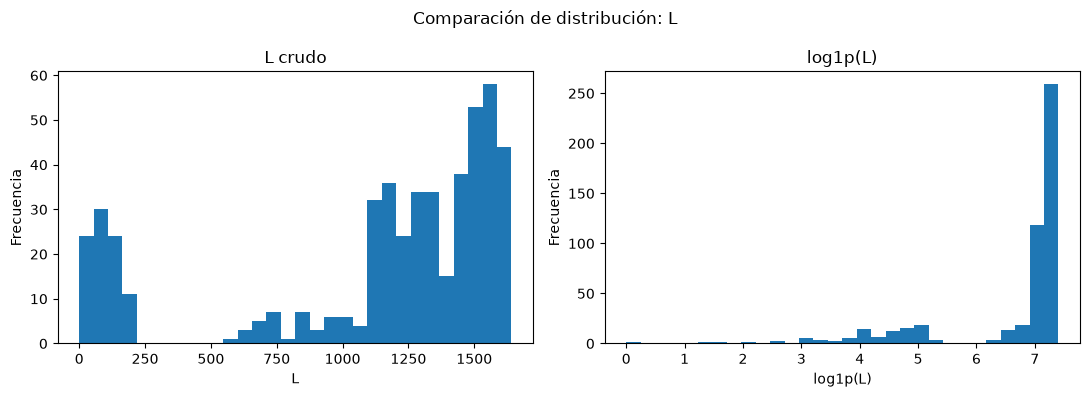

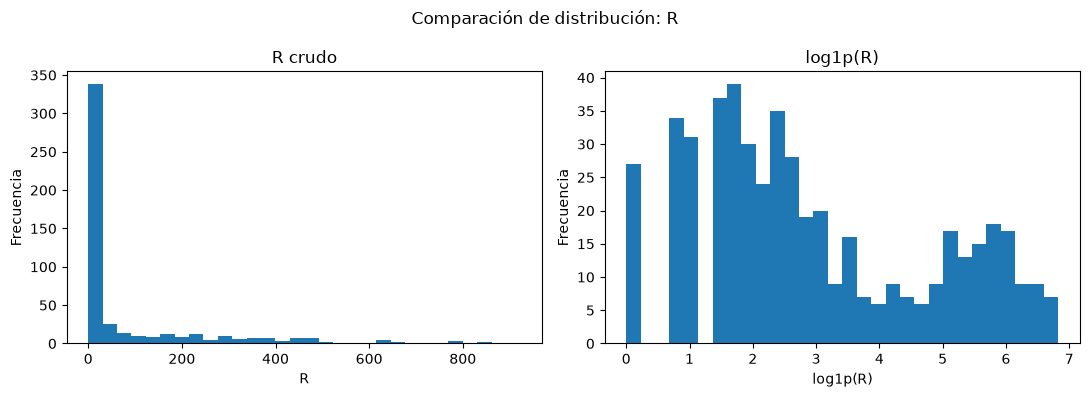

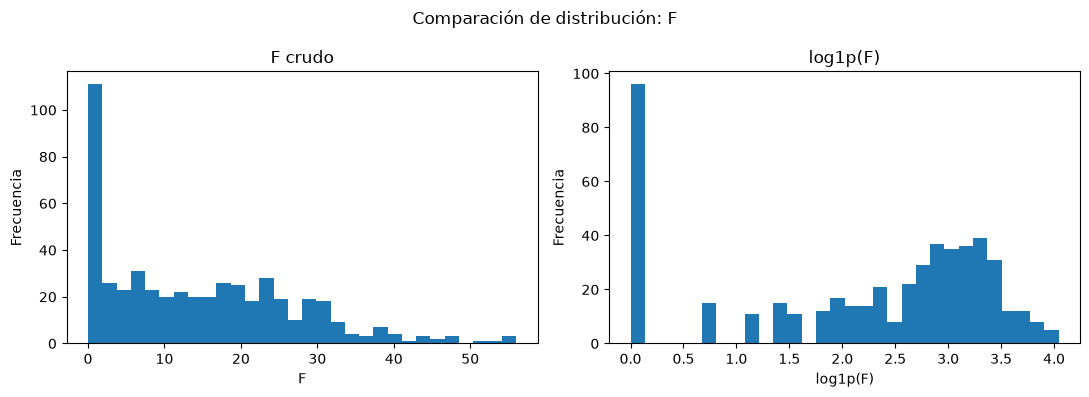

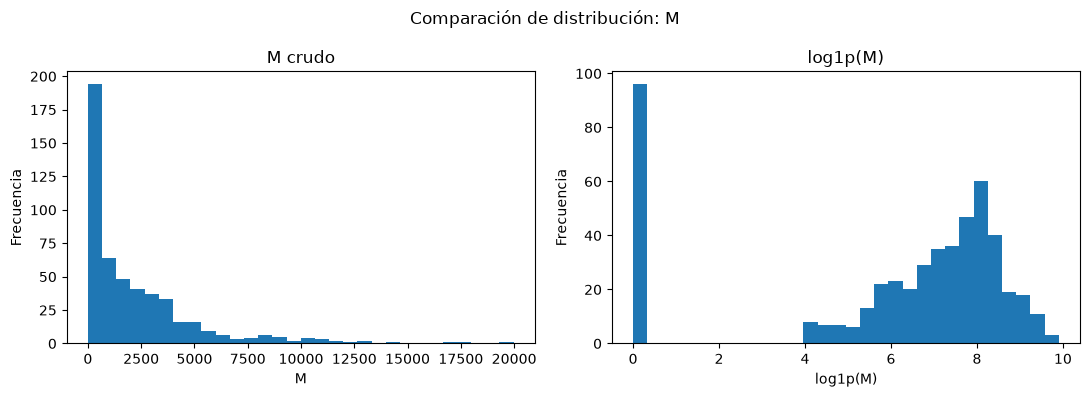

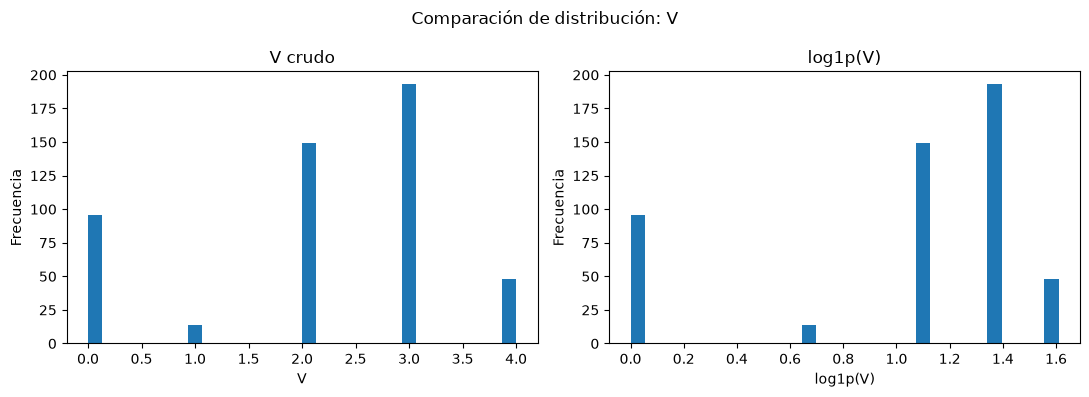

In [16]:
for col in LRFMV_COLUMNS:
    raw_values = df[col].dropna()
    log_values = np.log1p(raw_values)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].hist(raw_values, bins=30)
    axes[0].set_title(f"{col} crudo")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    axes[1].hist(log_values, bins=30)
    axes[1].set_title(f"log1p({col})")
    axes[1].set_xlabel(f"log1p({col})")
    axes[1].set_ylabel("Frecuencia")

    fig.suptitle(f"Comparación de distribución: {col}")
    fig.tight_layout()
    plt.show()

## 15. Matriz de correlación LRFMV

Esta matriz ayuda a detectar redundancia entre variables.

Ejemplo de interpretación:

- Si `L` y `F` están muy correlacionadas, todavía hay arrastre de antigüedad sobre frecuencia.
- Si `F` y `M` están muy correlacionadas, puede ser normal: más compras suelen implicar más monto.
- Si `R` se correlaciona negativamente con `F` o `M`, tiene sentido: clientes más recientes tienden a tener más actividad.

,L,R,F,M,V
L,1.00,0.20,0.28,0.34,0.18
R,0.20,1.00,-0.55,-0.38,-0.77
F,0.28,-0.55,1.00,0.86,0.76
M,0.34,-0.38,0.86,1.00,0.67
V,0.18,-0.77,0.76,0.67,1.00


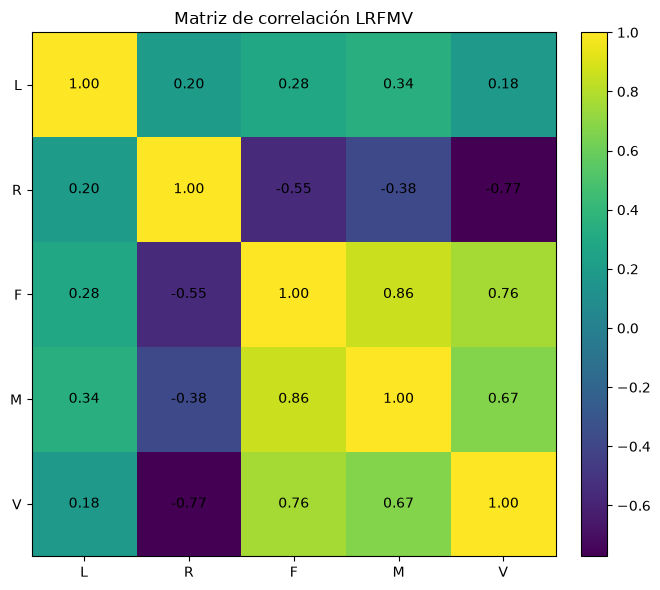

In [17]:
corr_lrfmv = df[["L", "R", "F", "M", "V"]].corr()

display(corr_lrfmv)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_lrfmv)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr_lrfmv.columns)))
ax.set_yticks(range(len(corr_lrfmv.index)))
ax.set_xticklabels(corr_lrfmv.columns)
ax.set_yticklabels(corr_lrfmv.index)

for i in range(len(corr_lrfmv.index)):
    for j in range(len(corr_lrfmv.columns)):
        ax.text(j, i, f"{corr_lrfmv.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("Matriz de correlación LRFMV")
fig.tight_layout()
plt.show()

## 16. Guardar salida Silver

In [18]:
clients_features.to_csv(CLIENTS_FEATURES_PATH, index=False)

eda_summary = {
    "snapshot_date": str(SNAPSHOT_DATE.date()),
    "observation_window_days": OBSERVATION_WINDOW_DAYS,
    "delta_window_days": DELTA_WINDOW_DAYS,
    "n_clients": int(len(clients_features)),
    "n_clients_without_transactions": int((~clients_features["has_transactions"]).sum()),
    "n_new_clients": int(clients_features["es_nuevo"].sum()),
    "n_low_history_clients": int(clients_features["low_history_flag"].sum()),
    "n_churn_eligible_clients": int(clients_features["churn_eligible"].sum()),
    "lrfmv_skew": skew_lrfmv.to_dict(),
    "lrfmv_correlation": corr_lrfmv.round(4).to_dict(),
    "categories_detected": all_categories,
}

with open(EDA_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, ensure_ascii=False, indent=2)

print("Archivo Silver generado:", CLIENTS_FEATURES_PATH)
print("Resumen EDA generado:", EDA_SUMMARY_PATH)

Archivo Silver generado: e:\proyecto_2026\2026-II\project_bebidas\bebidas-ds-project\modules\m2_lrfmv\notebooks\outputs\m2\silver\clients_features.csv
Resumen EDA generado: e:\proyecto_2026\2026-II\project_bebidas\bebidas-ds-project\modules\m2_lrfmv\notebooks\outputs\m2\silver\clients_features_eda_summary.json


## 17. Lectura de resultados

Al revisar este notebook, concéntrate en tres preguntas:

1. ¿`F`, `M` y `V` siguen estando demasiado correlacionadas con `L`?
2. ¿La transformación `log1p` reduce la asimetría de las variables más concentradas?
3. ¿La ventana de 180 días refleja bien el comportamiento comercial reciente para campaña?

Si la correlación entre `L` y las variables recientes queda controlada, podemos pasar luego a `silver.clients_normalized` con más seguridad.